# Growth and Challenges in Dutch Higher Education: Enrollment Trends and Future Projections

- Jens Groen (15853411)
- Thijs van der Meer (15831086)
- Sarah Kruse (15396142)



## Introduction

Dutch higher education is changing rapidly. More students are enrolling in universities and universities of applied sciences than ever before, and this trend brings both opportunities and challenges. In this data story, we explore how student numbers in the Netherlands have grown in recent years — and what the future might look like based on national projections.

We use open datasets from DUO (Dienst Uitvoering Onderwijs) to analyze actual enrollment figures between 2019 and 2023, and future forecasts up to 2038.

This story is for anyone curious about how demographic shifts and educational policies impact the future of higher education. Whether you are a student, educator, policymaker, or just interested in the Dutch education system, we invite you to explore the data with us.

In this data story project, we investigate the growth and challenges in Dutch higher education using two DUO datasets:
1. **Inschrijvingen WO (2019–2023)**  (University Enrollments (2019–2023)) 
2. **Aantallen en prognoses hogere opleidingen (2017–2038)**  (Numbers and Projections of Higher Education (2017–2038))

We highlight two perspectives:
- **Perspective 1:** Enrollment growth strengthens Dutch higher education quality.
- **Perspective 2:** This demographic decline poses a structural threat to the sustainability of academic programs, institutional funding, and the regional availability of higher education.

Each section is supported with visualizations created in Python.


## Preprocessing Overview

We begin by defining two lists of years—one for each dataset—to streamline subsequent operations. For the first dataset (`registraties_wo`), we list the years 2020 through 2024. For the second dataset (`pre_student_prognoses`), we list the years 2017 through 2024.

Next, we standardize any entries of “<5” by replacing them with “0” in both DataFrames. This ensures that all values are numeric (or zero), eliminating textual placeholders that would otherwise block numerical analysis.

Once the placeholders are handled, we convert the relevant columns into numeric data types. In the first dataset, each year column is cast to numeric, with any remaining non-numeric entries coerced into missing values (`NaN`). In the second dataset, we similarly convert each enrollment and flow-related column—such as ingeschrevenen_HO, instroom_RR, instroom_HO, tweedejaars_HO, hogerejaars_HO, instroom_THO_NW, tweedejaars_THO_NW, and hogerejaars_THO_NW—into numeric form, again coercing invalid entries to `NaN`.

Finally, we split the prognoses DataFrame into two subsets based on the `status` field. Rows marked as “realisatie” become the `student_realisatie` DataFrame (actual realized enrollments), while rows marked as “prognose” become the `student_prognoses` DataFrame (forecasted enrollments).

This sequence of steps yields two clean, numeric datasets—one capturing historical registrations and one differentiating between realized enrollments and future projections—ready for further analysis.


## Perspective 1: Enrollment growth strengthens Dutch higher education quality.
This perspective focuses on the positive impact of the growth in student enrollment in Dutch higher education. You can highlight benefits such as improved access to higher education, increased diversity, and a more educated workforce.

The sustained growth in student enrollment at Dutch higher education institutions signals improved accessibility and reflects society’s increasing valuation of higher qualifications. This trend expands educational opportunities, fosters a more educated workforce, and strengthens the international character of Dutch academia.

In [1]:
import plotly.graph_objs as go
import plotly.express as px
import pandas as pd
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"

registraties_wo = pd.read_csv('registraties_wo_pre_processed.csv')
student_prognoses = pd.read_csv('student_prognoses_pre_processed.csv')
student_realisatie = pd.read_csv('student_realisatie_pre_processed.csv')

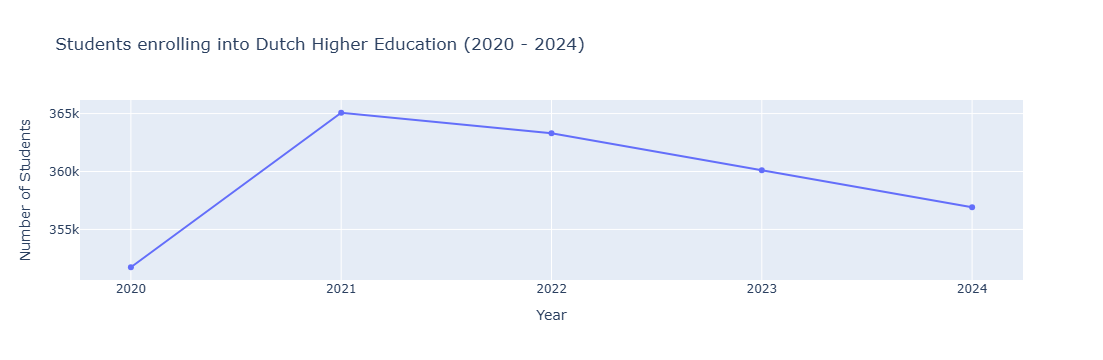

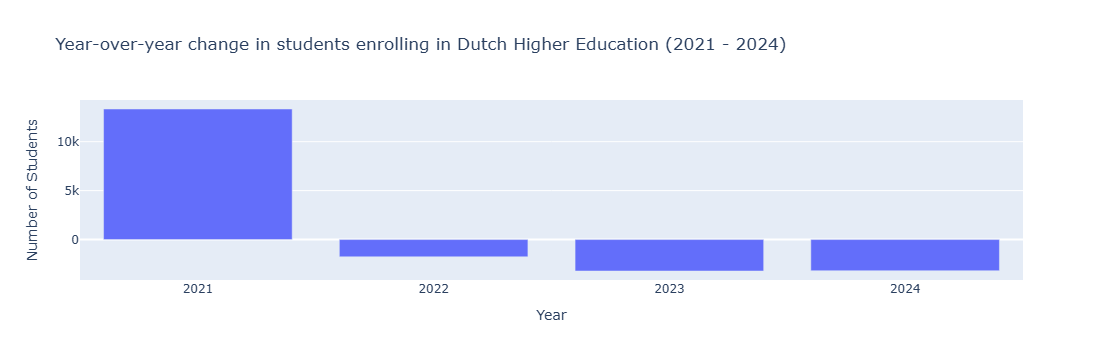

In [88]:
jaren = ['2020', '2021', '2022', '2023', '2024']
plt0 = go.Figure([go.Scatter(
    x = jaren,
    y = [registraties_wo[i].sum() for i in jaren]
)])
plt0.update_layout(title='Students enrolling into Dutch Higher Education (2020 - 2024)', height=600, xaxis_title="Year", yaxis_title="Number of Students")
plt0.show()

var = ['2021', '2022', '2023', '2024'] #list of years to use for the graph, removed 2020 because there is not data to compare.

plt1 = go.Figure([go.Bar(
    x=var,
    y=[(registraties_wo[i].sum() - (registraties_wo[str(int(i) - 1)].sum())) for i in var ], #dict comprehension to return a list of the change in enrollment of year i compared to the previous year
    
)])

plt1.update_layout(title="Year-over-year change in students enrolling in Dutch Higher Education (2021 - 2024)", height = 600,
                  xaxis_title="Year", yaxis_title="Number of Students")
plt1.show()

*Figure 1. Number of students starting university education in the Netherlands between 2020 and 2024, based on the dataset "Inschrijvingen WO (2019–2023)". While overall enrollment peaked in 2021, a slight decline is observed in the following years, indicating a stabilizing trend rather than a sharp drop.*


#### Increased Cultural Diversity
The growing number of international students at Dutch universities significantly contributes to cultural diversity within higher education. These students bring with them a wide range of perspectives, languages, customs, and ways of thinking, enriching the learning environment. This fosters intercultural understanding and helps both Dutch and international students develop the skills needed to collaborate effectively in an increasingly globalized world.

In addition, this diversity enhances knowledge exchange on both content and methodological levels. Due to their different academic backgrounds and approaches, international students introduce new insights into teaching and research. Universities benefit from this through group work, classroom discussions, and collaborative international research projects that integrate knowledge from multiple countries. As noted by Nuffic (2023), internationalization strengthens the quality of education and supports the development of global citizenship skills.

Moreover, the rise in international student numbers encourages institutions to design curricula and teaching methods that are more inclusive and internationally oriented. This includes the expansion of English-taught programs, the integration of intercultural training modules, and participation in international accreditation processes. These developments not only increase the appeal of Dutch universities but also strengthen their position in international rankings (OECD, 2024; Universities of the Netherlands, n.d.).



{2017: 729717.0, 2018: 747393.0, 2019: 767156.0, 2020: 816813.0, 2021: 832065.0, 2022: 817222.0, 2023: 800797.0, 2024: 788275.0}


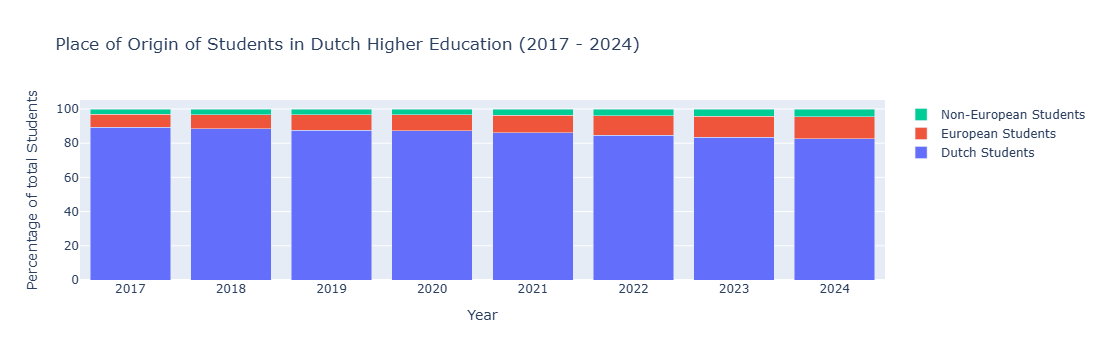

In [92]:
jaren2 = [2017, 2018, 2019, 2020, 2021,2022, 2023,2024]

Totaal = {jaar: student_realisatie[(student_realisatie['jaar'] == jaar)]['ingeschrevenen_HO'].sum() for jaar in jaren2}
print(Totaal)

#each list comprehension creates a list of the percentage of certain groups of students
totaal_NL = [(student_realisatie[(student_realisatie['jaar'] == jaar) & (student_realisatie['herkomst'] == 'NL')]['ingeschrevenen_HO'].sum() / Totaal[jaar]) * 100 for jaar in jaren2]
totaal_EER = [(student_realisatie[(student_realisatie['jaar'] == jaar) & (student_realisatie['herkomst'] == 'EER')]['ingeschrevenen_HO'].sum() / Totaal[jaar]) * 100 for jaar in jaren2]
totaal_niet_EER = [(student_realisatie[(student_realisatie['jaar'] == jaar) & (student_realisatie['herkomst'] == 'niet-EER')]['ingeschrevenen_HO'].sum() / Totaal[jaar]) * 100 for jaar in jaren2]



fig2 = go.Figure(data=[
    go.Bar(name='Dutch Students', x=jaren2, y=totaal_NL),
    go.Bar(name='European Students', x=jaren2, y=totaal_EER),
    go.Bar(name='Non-European Students', x=jaren2, y=totaal_niet_EER),
    
])

fig2.update_layout(barmode='stack', title='Place of Origin of Students in Dutch Higher Education (2017 - 2024)', height = 600, xaxis_title="Year",
    yaxis_title="Percentage of total Students")
fig2.show()

*Figure 2.*

#### Growth of a Highly Educated Workforce
The increase in student enrollment at Dutch universities — including the growing number of international students — indicates that higher education in the Netherlands has become more attractive to a broader and more diverse group. This trend can have positive societal effects, such as the growth of a highly educated workforce and enhanced international collaboration.

A larger student population leads to more graduates with university-level qualifications, directly contributing to a more skilled labor market. International students play a key role in this development. According to research by Nuffic (2023), approximately one in four international students still resides and works in the Netherlands five years after graduation. These graduates help strengthen the country’s knowledge economy and innovation capacity (SEO Economic Research, 2019).


In [5]:
student_realisatie



totaal_wo = [student_realisatie[(student_realisatie['jaar'] == jaar) & (student_realisatie['soort_ho'] == 'wo')]['ingeschrevenen_HO'].sum() / Totaal[jaar] * 100 for jaar in jaren2]
totaal_hbo = [student_realisatie[(student_realisatie['jaar'] == jaar) & (student_realisatie['soort_ho'] == 'hbo')]['ingeschrevenen_HO'].sum() / Totaal[jaar] * 100 for jaar in jaren2]

fig3 = go.Figure([
    go.Bar(y=totaal_hbo, x=jaren2, name='University'),
    go.Bar(y=totaal_wo, x=jaren2, name='HBO')
])

fig3.update_layout(barmode='stack', height=600)
fig3.show()


*Figure 3.*

### Gender Balance as a Sign of Inclusive Growth
The continued growth in student enrollment has been accompanied by a consistent gender pattern: female students have outnumbered male students every year between 2020 and 2024. The peak year 2021, which reflected delayed enrollment due to COVID-19, shows it most clearly. Both male and female enrollment are increasing, but women are consistently ahead in absolute numbers. This gender trend highlights a positive shift toward greater gender balance in higher education, which may contribute to more equal representation and opportunities for women in the labor market in the long term.  A higher share of female graduates contributes to a more balanced labor force, especially in sectors traditionally underrepresented by women. Promoting equal access for all genders enhances not only fairness but also economic resilience and innovation potential in a knowledge-based economy (Hong, Kim, Park & Sim, 2019).

In [6]:
totaal_vrouw = [registraties_wo[registraties_wo['GESLACHT'] == 'vrouw'][jaar].sum() for jaar in jaren]
totaal_man = [registraties_wo[registraties_wo['GESLACHT'] == 'man'][jaar].sum() for jaar in jaren]

fig4 = go.Figure(data = [
    go.Bar(name='Male students', x = jaren, y = totaal_man),
    go.Bar(name='Female students', x = jaren, y = totaal_vrouw)
])

fig4.update_layout( height = 600, title = 'Number of Students in Dutch Higher Education per Gender (2020 - 2024)')
fig4.show()


*Figure 4.*

## Perspective 2: This demographic decline poses a structural threat to the sustainability of academic programs, institutional funding, and the regional availability of higher education. 
Although student numbers in Dutch higher education have grown for years, recent DUO projections indicate a structural decline starting from 2025.
DUO expects a decline from approximately 780,000 students in 2025 to below 700,000 by 2038. This trend is not temporary nor incidental, but closely connected to broader societal and demographic shifts. As a result, the sustainability of particularly small-scale programs, regionally anchored institutions, and broad-based universities is coming under increasing pressure. This perspective highlights how the structural decline has uneven effects on different types of programs and regions, and why this calls for differentiated and forward-looking policies.


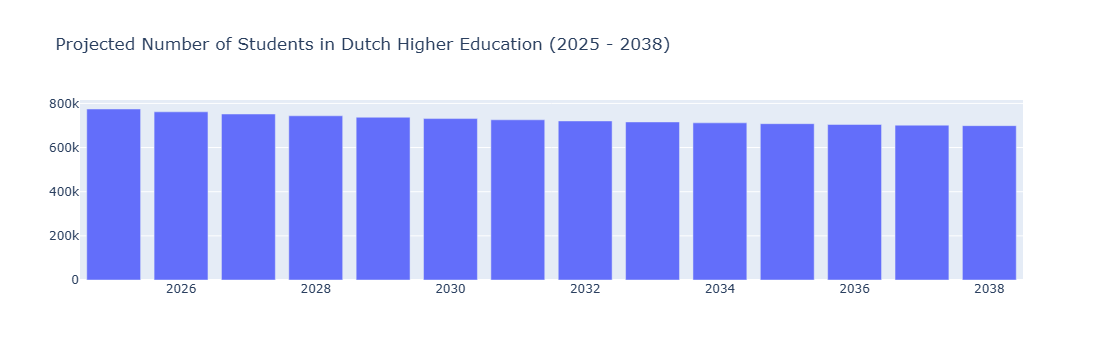

In [19]:

jaren3 = [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036, 2037, 2038]

fig5 = go.Figure([go.Bar(
    y = [student_prognoses[student_prognoses['jaar'] == jaar]['ingeschrevenen_HO'].sum() for jaar in jaren3],
    x = jaren3
)])
fig5.update_layout(title = 'Projected Number of Students in Dutch Higher Education (2025 - 2038)', height = 600)

fig5.show()

*Figure 5.*

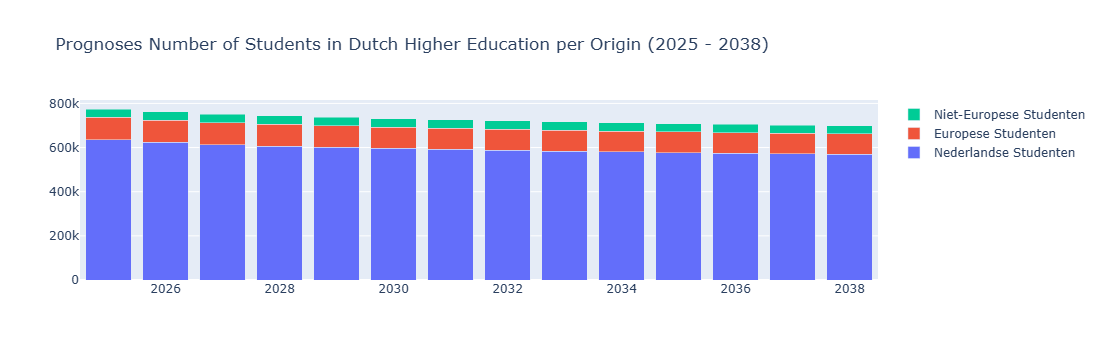

In [21]:
totaal_NL = []
totaal_EER = []
totaal_niet_EER = []

for jaar in jaren3:
    totaal = student_prognoses[
        (student_prognoses['jaar'] == jaar) & 
        (student_prognoses['herkomst'] == 'NL')
    ]['ingeschrevenen_HO'].sum()
    
    totaal_NL.append(totaal)

for jaar in jaren3:
    totaal = student_prognoses[
        (student_prognoses['jaar'] == jaar) & 
        (student_prognoses['herkomst'] == 'EER')
    ]['ingeschrevenen_HO'].sum()
    
    totaal_EER.append(totaal)

for jaar in jaren3:
    totaal = student_prognoses[
        (student_prognoses['jaar'] == jaar) & 
        (student_prognoses['herkomst'] == 'niet-EER')
    ]['ingeschrevenen_HO'].sum()
    
    totaal_niet_EER.append(totaal)

fig6 = go.Figure(data=[
    go.Bar(name='Nederlandse Studenten', x=jaren3, y=totaal_NL),
    go.Bar(name='Europese Studenten', x=jaren3, y=totaal_EER),
    go.Bar(name='Niet-Europese Studenten', x=jaren3, y=totaal_niet_EER),
])

fig6.update_layout(barmode='stack', title='Prognoses Number of Students in Dutch Higher Education per Origin (2025 - 2038)', height = 600)
fig6.show()

*Figure 6.*

### Risk of closure for smaller programs
As illustrated in Figure #, overall enrollment in higher education is projected to decline in the coming years. Notably, however, smaller academic programs do not appear to follow this trend, Their enrollment figures have remained stable, suggesting a continued demand for small-scale and specialized education. Santa (2018) notes that in Central Europe, programs failing to meet minimum standards cohort sizes face not only financial challenges but also the risk of suspension or consolidation. Yet, the data presented in Figure # indicates that these smaller programs continue to attracht a steady number of students. This highlights the importance of nuanced policymaking: instead of targeting programs solely based on size, distinctions should be made between those that are genuinely in decline and those that demonstrate stability. Only then can the academic landscape remain diverse and resilient.

In [24]:
# Visualisatie

### Unequal regional impact
Demographic decline does not affect all regions in the Netherlands equally. According to forecasts by Verwest, F., & Van Dam, F. (2010), the northern and eastern provinces—such as Groningen, Friesland, Drenthe, and parts of Limburg and Gelderland—are expected to experience a significant decrease in the youth population. As a result, universities in these areas, such as the University of Groningen or the University of Twente, may face a relatively sharper decline in student enrollment (Sá, Florax & Rietveld, 2004). This increases the risk of an unequal distribution of higher education across the Netherlands (Sá, Florax & Rietveld, 2004). Students from shrinking regions may be more likely to relocate to the Randstad, which undermines both the accessibility and regional connectedness of education. As illustrated in Figure #, projected enrollment trends clearly show that institutions located in peripheral regions are expected to experience a more pronounced decline compared to those in urban centers.

- Visualisatie idee (van chat): Kaart van Nederland met regionale inschrijvingsaantallen of verwachte daling per provincie of instelling. Of: Lijnengrafiek per regio/instituut met trend over tijd

In [27]:
# Visualisatie

*Figure #: Regional enrollment projections highlight this disparity. Institutions in peripheral regions show a steeper downward trend in projected student numbers compared to those in more urbanized areas, illustrating how demographic decline translates into regional educational imbalances.*

### Structural Pressure on Broad-Based Universities
The impact of demographic decline affects broad-based universities significantly more than specialized institutions. Broad institutions, such as large universities with multiple faculties, face higher fixed costs. These include extensive infrastructure, support services, and a wide range of academic programs, not all of which remain financially viable when student numbers drop. Projected student enrollment figures for the period 2025 to 2038 (see Figure #) show that broad-based institutions are expected to experience a steeper decline in enrollment on average than specialized universities or thematic institutions. While specialized institutions tend to maintain relatively stable intake, broad universities are projected to shrink substantially year over year. This trend is concerning, as the sustainability of broad universities depends not only on total student numbers but also on maintaining a critical mass per academic program. When that critical mass falls below a certain threshold, even core programs face the risk of suspension or consolidation. 

In [30]:
# Visualisatie

*Figure #*

# References
Hong, G., Kim, S., Park, G., & Sim, S.-G. (2019). Female Education Externality and Inclusive Growth. Sustainability, 11(12), 3344. https://doi.org/10.3390/su11123344

Nuffic. (2023). Incoming degree mobility in Dutch higher education. Retrieved from https://www.nuffic.nl/en/publications/incoming-degree-mobility-in-dutch-higher-education-2023-24

OECD. (2021). Education at a Glance 2021: OECD Indicators. OECD Publishing. Retrieved from https://www.oecd.org/en/publications/education-at-a-glance-2021_b35a14e5-en.html

OECD. (2024). Education at a Glance 2024: OECD Indicators. OECD Publishing. Retrieved from https://www.oecd.org/en/publications/education-at-a-glance-2024_c00cad36-en.html

Rathenau Instituut. (2024). Income and expenditure: Universities and higher education institutions. Retrieved from https://www.rathenau.nl/en/science-figures/investments/income-and-expenditure-universities-and-higher-education-institutions-0

Rijksoverheid. (n.d.). Financiering hoger onderwijs. Retrieved June 26, 2025, from https://www.rijksoverheid.nl/onderwerpen/financiering-onderwijs/financiering-hoger-onderwijs

Sá, C., Florax, R. J. G. M., & Rietveld, P. (2004). Determinants of the Regional Demand for Higher Education in The Netherlands: A Gravity Model Approach. Regional Studies, 38(4), 375–392. https://doi.org/10.1080/03434002000213905

Santa, R. (2018). The Future of European Higher Education in an Age of Demographic Headwinds: The Impact of Demographic Decline on Higher Education System Structures Funding in Romania, Poland, Russia. In A. Curaj, L. Deca, & R. Pricopie (Eds.), European Higher Education Area: The Impact of Past and Future Policies (pp. XXX–XXX). Springer, Cham. https://doi.org/10.1007/978-3-319-77407-7_23

SEO Economic Research. (2019). Foreign students in the Netherlands: Costs and benefits. Retrieved from https://www.seo.nl

Universities of the Netherlands. (n.d.). Internationalization in higher education. Retrieved from https://www.universiteitenvannederland.nl

Verwest, F., & Van Dam, F. (2010). From combating to managing: Demographic decline in the Netherlands – Policy strategies for current and future shrinking regions. The Hague: PBL Netherlands Environmental Assessment Agency. Retrieved from https://www.pbl.nl/sites/default/files/downloads/PBL_2012_From-combating-to-managing-demographic-decline-in-the-netherlands.pdf

# Reflection
In this project, we explored developments in Dutch higher education using data from DUO, focusing on university enrollments (WO) between 2019 and 2023, as well as forecasts up to 2038. We worked with two major datasets and developed two contrasting perspectives: on the one hand, that growth in student numbers strengthens the quality of higher education; and on the other hand, that demographic decline poses a structural threat to the sustainability of academic programs.

At the start of the project, we strongly believed that the data would show continued growth. That assumption shaped how we initially approached the analysis and how we started brainstorming perspectives. However, we soon discovered that after a peak in 2021, enrollment numbers had actually begun to decline slightly. This forced us to reevaluate our approach. It was frustrating at first, as many of our early ideas no longer aligned with the data.

In particular, developing the second perspective — that demographic decline threatens the higher education system — was challenging, especially because it contradicted our original expectations. But this realization pushed us to look at the numbers more critically and to better understand what the trends actually meant for the future of higher education. It was a valuable lesson: we learned the importance of letting the data speak for itself rather than trying to make it fit our assumptions.

Beyond the analytical work, the project also involved a lot of data preprocessing. We had to clean and transform the datasets — replacing placeholders like "<5", converting columns to numeric values, and splitting the data into realized versus projected figures. These technical tasks required precision and strong collaboration.

Creating visualizations in Python was another key part of the process. Visual tools helped us to recognize patterns and communicate insights more clearly. We came to appreciate just how powerful well-designed charts can be when telling a data-driven story — especially for complex, long-term trends like those in education.

In conclusion, this project was both challenging and instructive. We learned to adapt to unexpected results, to think critically based on data, and to collaborate in shaping a clear narrative. Going forward, we’ll be more prepared to consider multiple possible outcomes — and less likely to assume that growth is guaranteed.



## Work Distribution
- Jens: Visualizations
- Thijs: Introduction, preprocessing, GitHub
- Sarah: Perspectives, Formatting, Reflection